### Overview

Basic VAE for MNIST, using dimensionality discovered in PCA.ipynb (147 components for 95% variance)

In [2]:
import torch
from torch import nn
from torchvision import datasets, transforms
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt

In [3]:
mnist = datasets.MNIST(root='data', download=True)

Using device: cpu
Train samples (2 or 6): 11876
Test samples (2 or 6): 1990
Epoch 1/6 | beta: 0.000 | Train loss: 218.7817 | Test loss: 158.6719
Epoch 2/6 | beta: 0.000 | Train loss: 138.9459 | Test loss: 122.9055
Epoch 3/6 | beta: 0.000 | Train loss: 113.3285 | Test loss: 104.7491
Epoch 4/6 | beta: 0.000 | Train loss: 100.3433 | Test loss: 96.2138
Epoch 5/6 | beta: 0.000 | Train loss: 93.5260 | Test loss: 91.2612
Epoch 6/6 | beta: 0.000 | Train loss: 89.0695 | Test loss: 88.0427


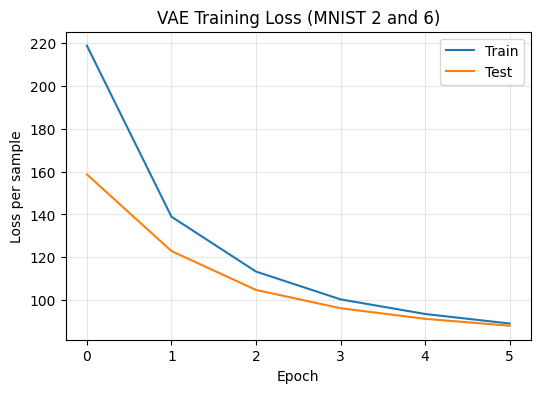

In [84]:
from torch.utils.data import DataLoader, Subset

# Hyperparameters
LATENT_DIM = 16
BATCH_SIZE = 128
EPOCHS = 6
LR = 1e-3

# KL annealing schedule
BETA_START = 0.0
BETA_END = 0
BETA_WARMUP_EPOCHS = EPOCHS

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# MNIST loaders (normalized to [0, 1])
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='data', train=False, transform=transform, download=True)

# Keep only digits 2 and 6
train_mask = (train_dataset.targets == 2) | (train_dataset.targets == 6)
test_mask = (test_dataset.targets == 2) | (test_dataset.targets == 6)

train_indices = torch.where(train_mask)[0]
test_indices = torch.where(test_mask)[0]

train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)

print(f'Train samples (2 or 6): {len(train_subset)}')
print(f'Test samples (2 or 6): {len(test_subset)}')

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)


class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=147):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x_hat = self.decoder(z)
        return x_hat.view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar


model = VAE(latent_dim=LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


def kl_weight(epoch, total_epochs, beta_start=0.0, beta_end=1.0, warmup_epochs=None):
    if warmup_epochs is None:
        warmup_epochs = total_epochs
    denom = max(warmup_epochs - 1, 1)
    progress = min(max((epoch - 1) / denom, 0.0), 1.0)
    return beta_start + progress * (beta_end - beta_start)


def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    # Reconstruction term + weighted KL divergence
    bce = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return bce + beta * kld, bce, kld


def train_epoch(model, loader, optimizer, device, beta=1.0):
    model.train()
    running_loss = 0.0
    for x, _ in loader:
        x = x.to(device)
        optimizer.zero_grad()
        recon_x, mu, logvar = model(x)
        loss, _, _ = vae_loss(recon_x, x, mu, logvar, beta=beta)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader.dataset)


def eval_epoch(model, loader, device, beta=1.0):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            recon_x, mu, logvar = model(x)
            loss, _, _ = vae_loss(recon_x, x, mu, logvar, beta=beta)
            running_loss += loss.item()
    return running_loss / len(loader.dataset)


train_losses = []
test_losses = []

for epoch in range(1, EPOCHS + 1):
    beta = kl_weight(
        epoch,
        EPOCHS,
        beta_start=BETA_START,
        beta_end=BETA_END,
        warmup_epochs=BETA_WARMUP_EPOCHS,
    )
    train_loss = train_epoch(model, train_loader, optimizer, device, beta=beta)
    test_loss = eval_epoch(model, test_loader, device, beta=beta)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    print(f'Epoch {epoch}/{EPOCHS} | beta: {beta:.3f} | Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f}')


# Plot train/test loss curve
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='Train')
plt.plot(test_losses, label='Test')
plt.xlabel('Epoch')
plt.ylabel('Loss per sample')
plt.title('VAE Training Loss (MNIST 2 and 6)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

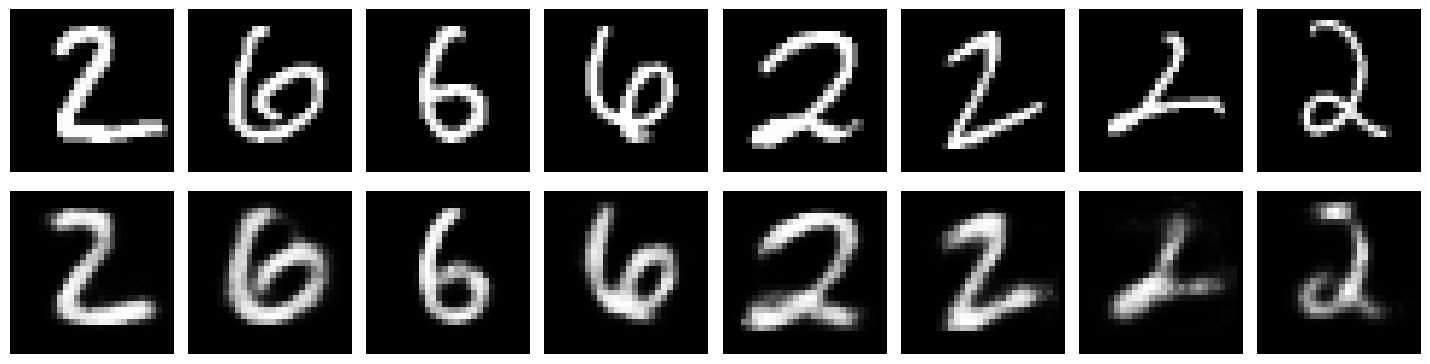

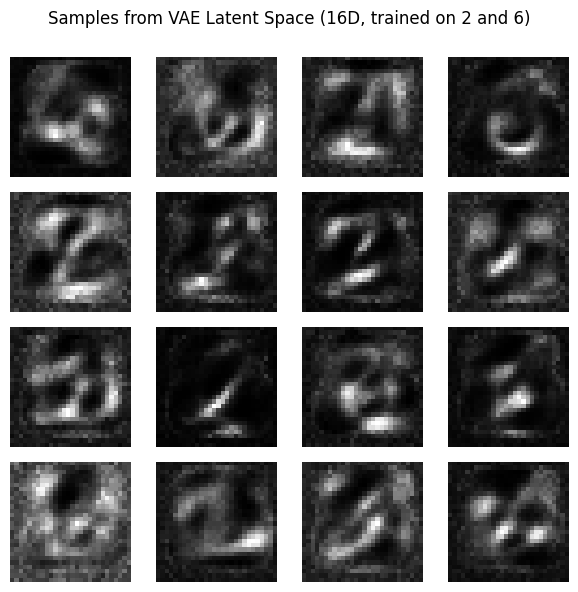

In [85]:
# Visualize reconstructions
model.eval()
with torch.no_grad():
    x_batch, _ = next(iter(test_loader))
    x_batch = x_batch.to(device)
    recon_batch, _, _ = model(x_batch)

n = 8
orig = x_batch[:n].cpu()
recon = recon_batch[:n].cpu()

fig, axes = plt.subplots(2, n, figsize=(1.8 * n, 4))
for i in range(n):
    axes[0, i].imshow(orig[i, 0], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recon[i, 0], cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Recon', fontsize=10)
plt.tight_layout()
plt.show()


# Sample from latent space and decode
with torch.no_grad():
    z = torch.randn(16, LATENT_DIM, device=device)
    samples = model.decode(z).cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i, 0], cmap='gray')
    ax.axis('off')
plt.suptitle(f'Samples from VAE Latent Space ({LATENT_DIM}D, trained on 2 and 6)')
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

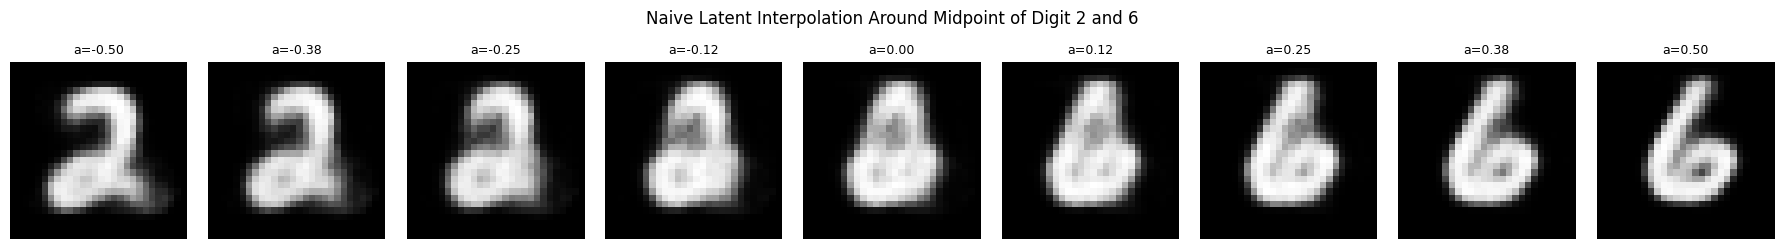

In [86]:
# Interpolation near the midpoint between class-2 and class-6 latent centroids (naive)
model.eval()

mu_2_list = []
mu_6_list = []

with torch.no_grad():
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        mu, logvar = model.encode(x)

        mask2 = (y == 2)
        mask6 = (y == 6)

        if mask2.any():
            mu_2_list.append(mu[mask2].cpu())
        if mask6.any():
            mu_6_list.append(mu[mask6].cpu())

        # Naive cap for speed
        if len(mu_2_list) >= 8 and len(mu_6_list) >= 8:
            break

mu2_centroid = torch.cat(mu_2_list, dim=0).mean(dim=0)
mu6_centroid = torch.cat(mu_6_list, dim=0).mean(dim=0)

midpoint = 0.5 * (mu2_centroid + mu6_centroid)
direction = mu6_centroid - mu2_centroid

# Sample points centered at midpoint and moving toward 2/6 directions
alphas = torch.linspace(-0.5, 0.5, steps=9)
z_interp = torch.stack([midpoint + a * direction for a in alphas], dim=0).to(device)

with torch.no_grad():
    interp_imgs = model.decode(z_interp).cpu()

fig, axes = plt.subplots(1, len(alphas), figsize=(2 * len(alphas), 2.4))
for i, ax in enumerate(axes):
    ax.imshow(interp_imgs[i, 0], cmap='gray')
    ax.set_title(f'a={alphas[i].item():.2f}', fontsize=9)
    ax.axis('off')
plt.suptitle('Naive Latent Interpolation Around Midpoint of Digit 2 and 6', y=1.02)
plt.tight_layout()
plt.show()

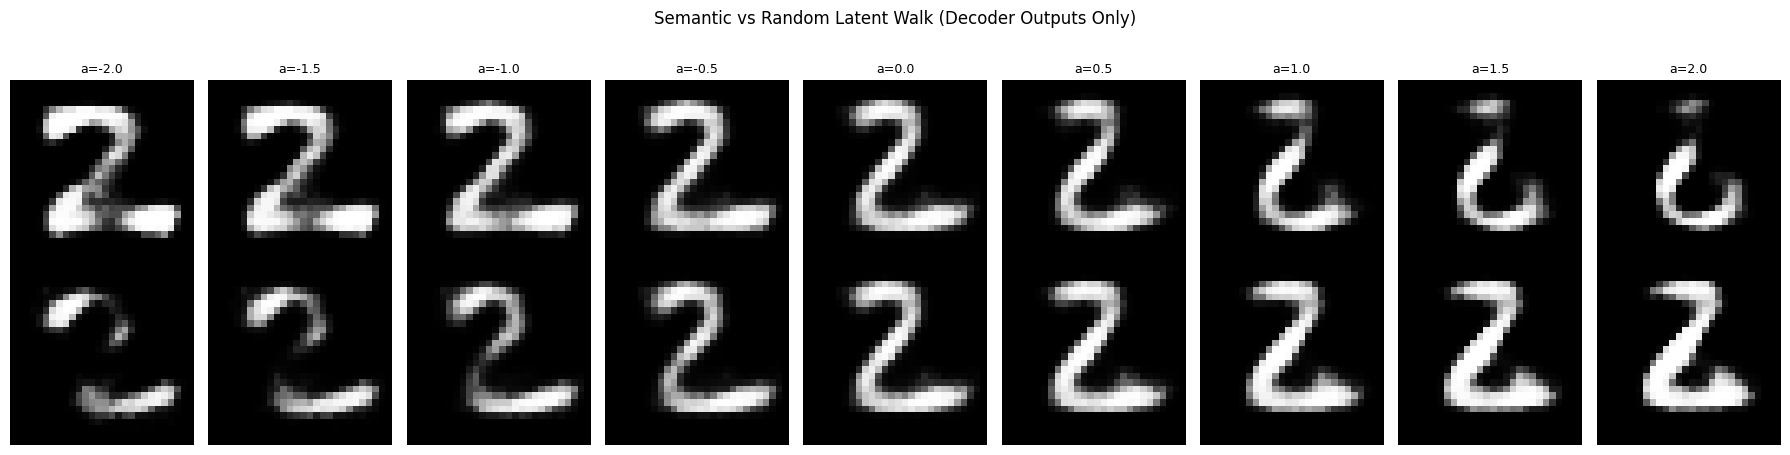

In [81]:
# Compare semantic latent walk (2->6 direction) vs random direction at matched scales
# All images are decoder outputs from latent vectors.
model.eval()

# 1) Build class direction in latent space from train-set encoded means
mu_2_list = []
mu_6_list = []

with torch.no_grad():
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        mu, _ = model.encode(x)

        mask2 = (y == 2)
        mask6 = (y == 6)
        if mask2.any():
            mu_2_list.append(mu[mask2].cpu())
        if mask6.any():
            mu_6_list.append(mu[mask6].cpu())

mu2_centroid = torch.cat(mu_2_list, dim=0).mean(dim=0)
mu6_centroid = torch.cat(mu_6_list, dim=0).mean(dim=0)

direction_sem = mu6_centroid - mu2_centroid
direction_sem = direction_sem / (torch.norm(direction_sem) + 1e-8)

# 2) Choose an anchor latent from test batch (prefer a 2)
with torch.no_grad():
    x_batch, y_batch = next(iter(test_loader))
    x_batch = x_batch.to(device)
    mu_batch, _ = model.encode(x_batch)

y_cpu = y_batch.cpu()
idx2 = torch.where(y_cpu == 2)[0]
anchor_idx = idx2[0].item() if len(idx2) > 0 else 0
z_anchor = mu_batch[anchor_idx].cpu()

# 3) Calibrate a meaningful step size using projection spread along semantic direction
mu2_all = torch.cat(mu_2_list, dim=0)
mu6_all = torch.cat(mu_6_list, dim=0)
mu_all = torch.cat([mu2_all, mu6_all], dim=0)
proj = (mu_all - z_anchor) @ direction_sem
step = torch.std(proj).item()
if step < 1e-4:
    step = 0.5

# 4) Build two walks with same alpha values
alphas = torch.tensor([-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0])

rand_dir = torch.randn_like(direction_sem)
rand_dir = rand_dir / (torch.norm(rand_dir) + 1e-8)

z_sem = torch.stack([z_anchor + (a.item() * step) * direction_sem for a in alphas], dim=0)
z_rand = torch.stack([z_anchor + (a.item() * step) * rand_dir for a in alphas], dim=0)

with torch.no_grad():
    imgs_sem = model.decode(z_sem.to(device)).cpu()
    imgs_rand = model.decode(z_rand.to(device)).cpu()

# 5) Plot comparison
cols = len(alphas)
fig, axes = plt.subplots(2, cols, figsize=(2.0 * cols, 4.4))

for i, a in enumerate(alphas):
    axes[0, i].imshow(imgs_sem[i, 0], cmap='gray')
    axes[0, i].set_title(f'a={a.item():.1f}', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(imgs_rand[i, 0], cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('2->6 direction', fontsize=10)
axes[1, 0].set_ylabel('random direction', fontsize=10)

plt.suptitle('Semantic vs Random Latent Walk (Decoder Outputs Only)', y=1.03)
plt.tight_layout()
plt.show()


=== Latent dim 8 ===
Run 1/3 | final test loss: 137.9740
Run 2/3 | final test loss: 138.1851
Run 3/3 | final test loss: 137.3737

=== Latent dim 16 ===
Run 1/3 | final test loss: 141.2687
Run 2/3 | final test loss: 140.6479
Run 3/3 | final test loss: 141.4534

=== Latent dim 32 ===
Run 1/3 | final test loss: 147.6274
Run 2/3 | final test loss: 145.0578
Run 3/3 | final test loss: 145.2729

=== Latent dim 64 ===
Run 1/3 | final test loss: 152.1952
Run 2/3 | final test loss: 152.0621
Run 3/3 | final test loss: 152.0671

=== Latent dim 80 ===
Run 1/3 | final test loss: 153.8608
Run 2/3 | final test loss: 152.8849
Run 3/3 | final test loss: 151.2194

=== Latent dim 147 ===
Run 1/3 | final test loss: 156.6419
Run 2/3 | final test loss: 155.6612
Run 3/3 | final test loss: 156.1141

=== Average final-epoch test loss by latent dimension ===
latent_dim   avg_final_test_loss         std    runs
         8              137.8443      0.3437       3
        16              141.1233      0.3445     

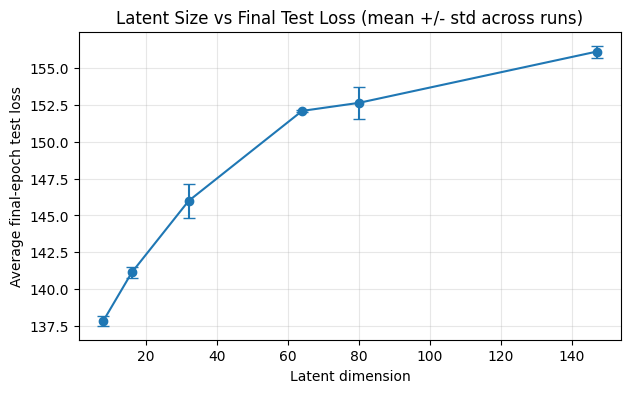

[{'latent_dim': 8,
  'runs': 3,
  'final_test_losses': [137.97396111416458,
   138.18511846341082,
   137.3736705990892],
  'avg_final_test_loss': 137.8442500588882,
  'std_final_test_loss': 0.34373500212005853},
 {'latent_dim': 16,
  'runs': 3,
  'final_test_losses': [141.26865970477388,
   140.64786284940325,
   141.45339441347363],
  'avg_final_test_loss': 141.1233056558836,
  'std_final_test_loss': 0.3445442640406973},
 {'latent_dim': 32,
  'runs': 3,
  'final_test_losses': [147.62739233275755,
   145.05778158369975,
   145.2728834602701],
  'avg_final_test_loss': 145.9860191255758,
  'std_final_test_loss': 1.1639435004233398},
 {'latent_dim': 64,
  'runs': 3,
  'final_test_losses': [152.19516773319722,
   152.06212753219222,
   152.06712468592966],
  'avg_final_test_loss': 152.10813998377304,
  'std_final_test_loss': 0.06157171841978849},
 {'latent_dim': 80,
  'runs': 3,
  'final_test_losses': [153.86075592807788,
   152.8848991048995,
   151.21939089981157],
  'avg_final_test_los

In [39]:
# Compare latent dimensions by averaging final-epoch test loss across repeated runs
latent_dims = [8, 16, 32, 64, 80, 147]
runs_per_dim = 3

latent_dim_results = []

for latent_dim in latent_dims:
    final_test_losses = []
    print(f"\n=== Latent dim {latent_dim} ===")

    for run_idx in range(1, runs_per_dim + 1):
        model_n = VAE(latent_dim=latent_dim).to(device)
        optimizer_n = torch.optim.Adam(model_n.parameters(), lr=LR)

        test_loss = None
        for epoch in range(1, EPOCHS + 1):
            beta = kl_weight(
                epoch,
                EPOCHS,
                beta_start=BETA_START,
                beta_end=BETA_END,
                warmup_epochs=BETA_WARMUP_EPOCHS,
            )
            _ = train_epoch(model_n, train_loader, optimizer_n, device, beta=beta)
            test_loss = eval_epoch(model_n, test_loader, device, beta=beta)

        final_test_losses.append(test_loss)
        print(f"Run {run_idx}/{runs_per_dim} | final test loss: {test_loss:.4f}")

    mean_final_test_loss = float(np.mean(final_test_losses))
    std_final_test_loss = float(np.std(final_test_losses))

    latent_dim_results.append({
        "latent_dim": latent_dim,
        "runs": runs_per_dim,
        "final_test_losses": final_test_losses,
        "avg_final_test_loss": mean_final_test_loss,
        "std_final_test_loss": std_final_test_loss,
    })

# Sort by average final test loss (lower is better)
latent_dim_results = sorted(latent_dim_results, key=lambda d: d["avg_final_test_loss"])

print("\n=== Average final-epoch test loss by latent dimension ===")
print(f"{'latent_dim':>10}  {'avg_final_test_loss':>20}  {'std':>10}  {'runs':>6}")
for row in latent_dim_results:
    print(
        f"{row['latent_dim']:>10}  "
        f"{row['avg_final_test_loss']:>20.4f}  "
        f"{row['std_final_test_loss']:>10.4f}  "
        f"{row['runs']:>6}"
    )

# Optional plot for quick visual comparison
dims = [row['latent_dim'] for row in latent_dim_results]
means = [row['avg_final_test_loss'] for row in latent_dim_results]
stds = [row['std_final_test_loss'] for row in latent_dim_results]

plt.figure(figsize=(7, 4))
plt.errorbar(dims, means, yerr=stds, fmt='o-', capsize=4)
plt.xlabel('Latent dimension')
plt.ylabel('Average final-epoch test loss')
plt.title('Latent Size vs Final Test Loss (mean +/- std across runs)')
plt.grid(alpha=0.3)
plt.show()

# `latent_dim_results` now stores all results for downstream use/comparison
latent_dim_results